<a href="https://colab.research.google.com/github/eliasakalu/ICogLabs_AI_Projects/blob/main/Neural_Network_and_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
#Load the data from cifar10 dataset
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()
#Cifar 10 target output
target_class=["Airplane", "Car", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship","Truck"]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
#Normalize the values
x_train=x_train/255
x_test=x_test/255

In [4]:
#Model
model=tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(32,32,3)),
    tf.keras.layers.Dense(units=128,activation='relu'),
    tf.keras.layers.Dense(units=64,activation='relu'),
    tf.keras.layers.Dense(units=32,activation='relu'),
    tf.keras.layers.Dense(units=10,activation='softmax'),

])
model.compile(optimizer="adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=["accuracy"])
model.fit(x_train,y_train,epochs=10,batch_size=32,validation_split=0.2)
model.summary()
loss,accuracy=model.evaluate(x_test,y_test)
print(f"The loss is {loss} and accuracy {accuracy}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.2991 - loss: 1.9171 - val_accuracy: 0.3263 - val_loss: 1.8437
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3638 - loss: 1.7537 - val_accuracy: 0.3860 - val_loss: 1.7036
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3957 - loss: 1.6778 - val_accuracy: 0.4032 - val_loss: 1.6701
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4194 - loss: 1.6193 - val_accuracy: 0.4192 - val_loss: 1.6362
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4350 - loss: 1.5812 - val_accuracy: 0.4219 - val_loss: 1.6463
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4448 - loss: 1.5516 - val_accuracy: 0.4184 - val_loss: 1.6255
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4524 - loss: 1.5302 - val_accuracy: 0.4454 - val_loss: 1.5806
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4617 - loss: 1.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,032 (4.62 MB)

 Trainable params: 404,010 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 808,022 (3.08 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4656 - loss: 1.5112
The loss is 1.5111957788467407 and accuracy 0.46560001373291016


In [5]:
#Uploading the image
from google.colab import files
image=files.upload()
image=list(image.keys())[0]

Saving download (2).jpg to download (2).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
This object is Airplane


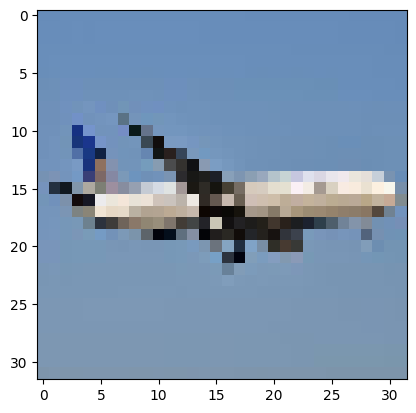

In [6]:
#After resizing the shape of image it tries to predict
img=cv2.imread(image)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

#Resize the image into 32X32 px
img=cv2.resize(img,(32,32))
#Normalize the image
img=img.astype("float32")/255
#Reshape it so that it will become compatible

data=img.reshape(1,32,32,3)

predicted=np.argmax(model.predict(data))
print(f"This object is {target_class[predicted]}")
plt.imshow(img)

# **Using CNN**

In [7]:
cnn_model=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64,activation="relu"),
    tf.keras.layers.Dense(units=10,activation="softmax")
])
cnn_model.compile(optimizer="adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=["accuracy"])
cnn_model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,batch_size=32)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.4372 - loss: 1.5390 - val_accuracy: 0.5109 - val_loss: 1.3596
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.5691 - loss: 1.2066 - val_accuracy: 0.5872 - val_loss: 1.1545
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 38ms/step - accuracy: 0.6279 - loss: 1.0577 - val_accuracy: 0.6548 - val_loss: 0.9961
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.6607 - loss: 0.9668 - val_accuracy: 0.6619 - val_loss: 0.9647
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6860 - loss: 0.8961 - val_accuracy: 0.6787 - val_loss: 0.9273
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7074 - loss: 0.8336 - val_accuracy: 0.6809 - val_loss: 0.9051
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - accuracy: 0.7247 - loss: 0.7882 - val_accuracy: 0.6925 - val_loss: 0.8886
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.7365 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,032 (4.62 MB)

 Trainable params: 404,010 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 808,022 (3.08 MB)

Saving images (1).jpg to images (1).jpg
(32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
This object is Horse


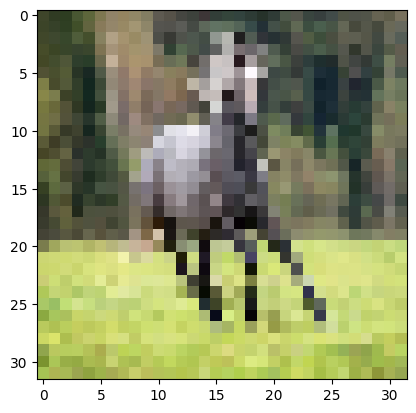

In [8]:
#After resizing the shape of image it tries to predict using CNN
image=files.upload()
image=list(image.keys())[0]
from cv2.gapi import BGR2RGB
img=cv2.imread(image,cv2.IMREAD_COLOR_RGB)

#Resize the image into 32X32 px
img=cv2.resize(img,(32,32))
#Normalize the image
img=img.astype("float32")/255
#Reshape it so that it will become compatible

print(img.shape)
data=img.reshape(1,32,32,3)

predicted=np.argmax(cnn_model.predict(data))
print(f"This object is {target_class[predicted]}")
plt.imshow(img)